<a href="https://colab.research.google.com/github/lisagamilton/python_tasks_logical/blob/main/pandas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://drive.google.com/file/d/1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX/view?usp=sharing

https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists?resource=download

In [2]:
! gdown --id 1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX
To: /content/HR_analytics.zip
100% 302k/302k [00:00<00:00, 24.5MB/s]


In [2]:
! unzip /content/HR_analytics.zip

Archive:  /content/HR_analytics.zip
replace aug_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
import pandas as pd
df = pd.read_csv('/content/aug_train.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [5]:
len(df)

19158

In [4]:
t = df.groupby('gender',dropna=False)['target'].agg(['count','mean'])
t

,count,mean
gender,,
Female,1238,0.263328
Male,13221,0.227819
Other,191,0.261780
NaN,4508,0.308119


In [6]:
#checksum verification
t['count'].sum()

np.int64(19158)

In [8]:
df.groupby('education_level',dropna=False)['target'].agg(['count','mean'])

,count,mean
education_level,,
Graduate,11598,0.279790
High School,2017,0.195340
Masters,4361,0.214400
Phd,414,0.140097
Primary School,308,0.133117
NaN,460,0.226087


In [7]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Categorical variables

<Axes: xlabel='education_level'>

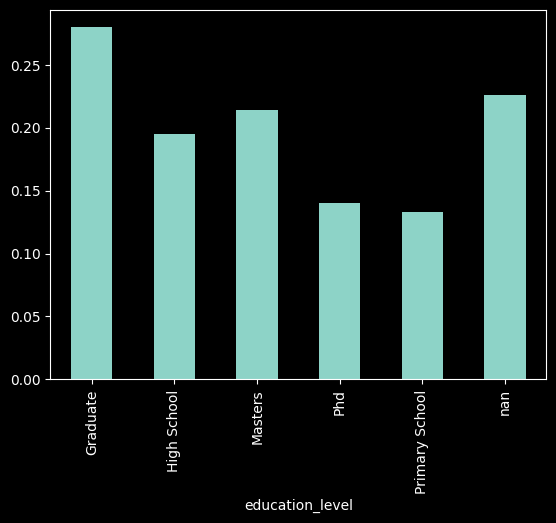

In [9]:
df.groupby('education_level',dropna=False)['target'].mean().plot(kind='bar')

# Numerical variables

In [34]:
df['city_development_index_group'] = pd.cut(df['city_development_index'],5)

In [35]:
df.groupby('city_development_index_group',dropna=False)['target'].agg(['count','mean'])

/tmp/ipykernel_2253/3697534609.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('city_development_index_group',dropna=False)['target'].agg(['count','mean'])


,count,mean
city_development_index_group,,
"(0.447, 0.548]",178,0.578652
"(0.548, 0.648]",3297,0.582651
"(0.648, 0.749]",1529,0.273381
"(0.749, 0.849]",1949,0.194459
"(0.849, 0.949]",12205,0.160262


<Axes: >

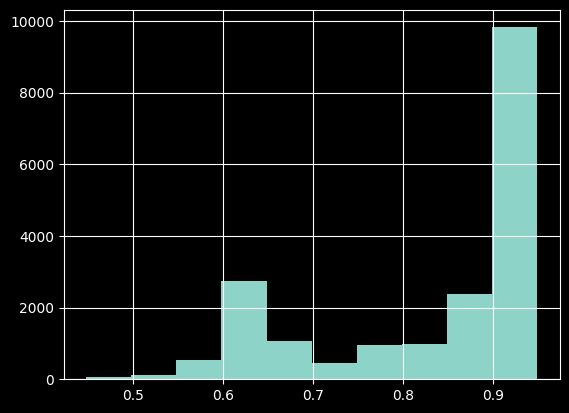

In [37]:
df['city_development_index'].hist()

In [38]:
df['city_development_index_group_q'] = pd.qcut(df['city_development_index'],5,duplicates='drop')

In [39]:
df.groupby('city_development_index_group_q',dropna=False)['target'].agg(['count','mean'])

/tmp/ipykernel_2253/3018231713.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('city_development_index_group_q',dropna=False)['target'].agg(['count','mean'])


,count,mean
city_development_index_group_q,,
"(0.447, 0.691]",3869,0.550530
"(0.691, 0.878]",3827,0.206428
"(0.878, 0.92]",8925,0.178375
"(0.92, 0.949]",2537,0.104454


In [11]:
df.groupby('gender')['training_hours'].mean()

,training_hours
gender,
Female,65.636511
Male,65.297633
Other,63.869110


In [12]:
df['education_level'].value_counts(dropna=False)

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
NaN,460
Phd,414
Primary School,308


In [13]:
df.groupby('relevent_experience')['target'].mean()

,target
relevent_experience,
Has relevent experience,0.214690
No relevent experience,0.338427


<Axes: xlabel='education_level'>

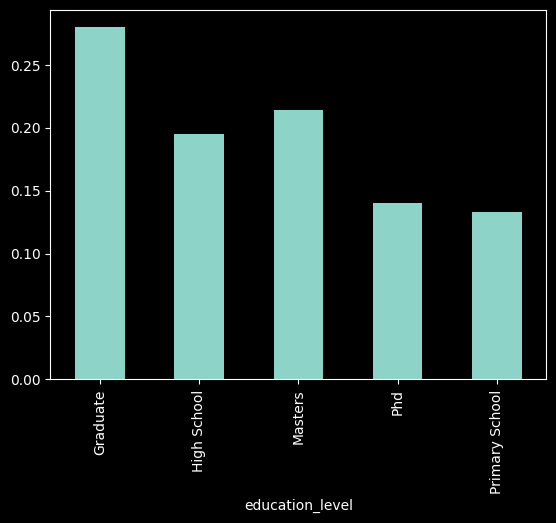

In [14]:
df.groupby('education_level')['target'].mean().plot(kind='bar')

In [15]:
df[df['city']=='city_103'].groupby('city')['target'].mean()

,target
city,
city_103,0.213088


In [16]:
#high_training = 1 якщо training_hours > 100 інакше 0
df['high_training'] = (df['training_hours'] > 100).astype(int)

In [17]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,high_training
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,0


In [18]:
df.groupby(['gender','education_level'])['target'].mean()

gender  education_level
Female  Graduate           0.279431
        High School        0.268657
        Masters            0.247788
        Phd                0.127660
        Primary School     0.250000
Male    Graduate           0.257122
        High School        0.182796
        Masters            0.191410
        Phd                0.132143
        Primary School     0.093596
Other   Graduate           0.330357
        High School        0.181818
        Masters            0.074074
        Phd                0.250000
        Primary School     0.333333
Name: target, dtype: float64

In [19]:
df.groupby(['education_level','gender'])['target'].mean()

education_level  gender
Graduate         Female    0.279431
                 Male      0.257122
                 Other     0.330357
High School      Female    0.268657
                 Male      0.182796
                 Other     0.181818
Masters          Female    0.247788
                 Male      0.191410
                 Other     0.074074
Phd              Female    0.127660
                 Male      0.132143
                 Other     0.250000
Primary School   Female    0.250000
                 Male      0.093596
                 Other     0.333333
Name: target, dtype: float64

In [20]:
#who is searching for a new job among company sizes
df.groupby('company_size')['target'].mean()

,target
company_size,
10/49,0.233855
100-500,0.161416
1000-4999,0.150602
10000+,0.190688
50-99,0.176776
500-999,0.173318
5000-9999,0.181172
<10,0.171254


In [21]:
#top 5 cities where max mean target
df.groupby('city')['target'].mean().sort_values(ascending=False).head(5)

,target
city,
city_171,1.000000
city_139,0.800000
city_155,0.785714
city_42,0.692308
city_107,0.666667


In [22]:
#середній training_hours тільки для людей з target = 1
mean_avg = df[df['target'] == 1]['training_hours'].mean()
mean_avg

np.float64(63.11848440443793)

In [23]:
#середній target тільки для людей з experience > 10
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,high_training
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0,0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0,0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0,0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0,0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0,1


In [24]:
#топ-3 education_level з найбільшим training_hours
df.groupby('education_level')['training_hours'].mean().sort_values(ascending=False).head(3)

,training_hours
education_level,
Phd,67.524155
High School,66.680714
Graduate,65.773409


In [25]:
#для кожного gender скільки людей (count) і середній target
df.groupby('gender')['target'].agg(['count','mean'])

,count,mean
gender,,
Female,1238,0.263328
Male,13221,0.227819
Other,191,0.261780


In [26]:
df.groupby(['gender', 'company_size'])['target'].mean()

gender  company_size
Female  10/49           0.247525
        100-500         0.144578
        1000-4999       0.112150
        10000+          0.123188
        50-99           0.140187
        500-999         0.253968
        5000-9999       0.200000
        <10             0.178082
Male    10/49           0.206226
        100-500         0.153358
        1000-4999       0.145161
        10000+          0.179073
        50-99           0.156826
        500-999         0.147059
        5000-9999       0.158416
        <10             0.147219
Other   10/49           0.166667
        100-500         0.000000
        1000-4999       0.153846
        10000+          0.136364
        50-99           0.193548
        500-999         0.000000
        5000-9999       0.200000
        <10             0.181818
Name: target, dtype: float64

In [27]:
data = {'Name': ['Alice', 'Bob', 'Charlie'], 'Age': [25, 30, 35],
            'City': ['New York', 'Los Angeles', 'Chicago']}
frame = pd.DataFrame.from_dict(data)
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Age     3 non-null      int64 
 2   City    3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


In [28]:
age_filter = frame[frame['Age'] > 30]
age_filter

,Name,Age,City
2,Charlie,35,Chicago


In [29]:
frame['Age_plus_5'] = frame['Age'] + 5
frame

,Name,Age,City,Age_plus_5
0,Alice,25,New York,30
1,Bob,30,Los Angeles,35
2,Charlie,35,Chicago,40


In [30]:
frame.groupby('City')['Age'].mean()

,Age
City,
Chicago,35.0
Los Angeles,30.0
New York,25.0


In [31]:
df1 = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['Alice', 'Bob', 'Charlie']})
df2 = pd.DataFrame({'ID': [1, 2, 3], 'Age': [25, 30, 35]})

merged_df = df1.merge(df2,on = 'ID')
merged_df

,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35


# Functions in pandas

In [41]:
def education_group(x):
  if x in ['High School','Primary School']:
    return 'School'
  if x in ['Masters','Phd']:
    return 'Masters and Phd'
  return x

In [43]:
df['new_educational_level'] = df['education_level'].apply(education_group)

In [45]:
df.groupby('new_educational_level')['target'].agg(['count','mean'])

,count,mean
new_educational_level,,
Graduate,11598,0.279790
Masters and Phd,4775,0.207958
School,2325,0.187097


In [62]:
def new_training_hours(row):
    if row['education_level'] == 'Phd':   # ← тут має бути точно так
        return row['training_hours'] + 1000
    return row['training_hours']

In [71]:
df['new_training_hours']= df.apply(new_training_hours,axis=1)

In [72]:
df[df['education_level'] == 'Phd']

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,high_training,city_development_index_group,city_development_index_group_q,new_educational_level,C,new_training_hours
37,10164,city_114,0.926,Male,Has relevent experience,no_enrollment,Phd,STEM,>20,100-500,Pvt Ltd,4,42,1.0,0,"(0.849, 0.949]","(0.92, 0.949]",Masters and Phd,low,1042
121,13915,city_16,0.910,Male,Has relevent experience,no_enrollment,Phd,STEM,>20,100-500,Pvt Ltd,2,20,1.0,0,"(0.849, 0.949]","(0.878, 0.92]",Masters and Phd,low,1020
130,3921,city_36,0.893,NaN,No relevent experience,no_enrollment,Phd,STEM,>20,1000-4999,Public Sector,>4,4,0.0,0,"(0.849, 0.949]","(0.878, 0.92]",Masters and Phd,low,1004
135,23947,city_103,0.920,NaN,No relevent experience,no_enrollment,Phd,STEM,NaN,NaN,NaN,NaN,70,0.0,0,"(0.849, 0.949]","(0.878, 0.92]",Masters and Phd,high,1070
152,31786,city_103,0.920,Male,No relevent experience,no_enrollment,Phd,STEM,>20,50-99,Pvt Ltd,>4,14,0.0,0,"(0.849, 0.949]","(0.878, 0.92]",Masters and Phd,low,1014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18738,1477,city_162,0.767,Male,Has relevent experience,no_enrollment,Phd,STEM,>20,10000+,Pvt Ltd,1,34,0.0,0,"(0.749, 0.849]","(0.691, 0.878]",Masters and Phd,low,1034
18800,18365,city_103,0.920,Male,Has relevent experience,no_enrollment,Phd,STEM,15,50-99,Funded Startup,4,108,0.0,1,"(0.849, 0.949]","(0.878, 0.92]",Masters and Phd,high,1108
18807,229,city_114,0.926,Male,No relevent experience,no_enrollment,Phd,STEM,14,5000-9999,Public Sector,>4,9,1.0,0,"(0.849, 0.949]","(0.92, 0.949]",Masters and Phd,low,1009
18944,2678,city_104,0.924,NaN,No relevent experience,no_enrollment,Phd,STEM,>20,50-99,Pvt Ltd,NaN,27,0.0,0,"(0.849, 0.949]","(0.92, 0.949]",Masters and Phd,low,1027


In [65]:
#Колонку C: якщо training_hours > 50 → "high" інакше → "low"
def training_hours_group(row):
  if row['training_hours'] >50:
    return 'high'
  return 'low'

In [68]:
df['C'] = df.apply(training_hours_group,axis=1)
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,high_training,city_development_index_group,city_development_index_group_q,new_educational_level,C
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,0,"(0.849, 0.949]","(0.878, 0.92]",Graduate,low
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0,"(0.749, 0.849]","(0.691, 0.878]",Graduate,low
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,0,"(0.548, 0.648]","(0.447, 0.691]",Graduate,high
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0,"(0.749, 0.849]","(0.691, 0.878]",Graduate,high
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,0,"(0.749, 0.849]","(0.691, 0.878]",Masters and Phd,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0,0,"(0.849, 0.949]","(0.691, 0.878]",Graduate,low
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0,0,"(0.849, 0.949]","(0.878, 0.92]",Graduate,high
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0,0,"(0.849, 0.949]","(0.878, 0.92]",Graduate,low
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0,0,"(0.749, 0.849]","(0.691, 0.878]",School,high
